In [1]:
%pip install tabulate graphviz

import torch
from pytorch_nndct.apis import Inspector
from torch import nn


[notice] A new release of pip is available: 23.1.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[VAIQ_NOTE]: Loading NNDCT kernels...


No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


In [2]:
class BaselineNet(nn.Module):
    def __init__(self):
        super(BaselineNet, self).__init__()
        self.cv1 = nn.Conv3d(1, 32, kernel_size=(5, 3, 5), stride=(2, 1, 2), padding=0)
        self.cv2 = nn.Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=0)
        self.pol1 = nn.MaxPool3d(2)
        self.fc1 = nn.Linear(6912, 128)
        self.act1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 4)
        self.act2 = nn.Softmax(dim=1)

    def forward(self, input):
        c1 = self.cv1(input)
        c2 = self.cv2(c1)
        p1 = self.pol1(c2)
        s1 = self.fc1(torch.flatten(p1, 1))
        a1 = self.act1(s1)
        s2 = self.fc2(a1)
        output = self.act2(s2)
        return output

Check available targets at: https://github.com/Xilinx/Vitis-AI/tree/1eed93cde2ff3ed841ddb03dff0714b4e2d34f5b/src/vai_runtime/target_factory/targets

In [3]:
# Specify a target name or fingerprint you want to deploy on
#target = "DPUCZDX8G_ISA1_B3136" # ZCU104
target = "DPUCAHX8H_ISA2" # Alveo HBM
# Initialize inspector with target
inspector = Inspector(target)


[VAIQ_NOTE]: Inspector is on.


In [4]:
# Start to inspect the float model
# Note: visualization of inspection results relies on the dot engine.If you don't install dot successfully, set 'image_format = None' when inspecting.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineNet()
dummy_input = torch.randn(1, 1, 32, 16, 32)
inspector.inspect(model, (dummy_input,), device=device, output_dir="inspect", image_format="png") 


[VAIQ_NOTE]: =>Start to inspect model...

[VAIQ_NOTE]: =>Quant Module is in 'cpu'.

[VAIQ_NOTE]: =>Parsing BaselineNet...

[VAIQ_NOTE]: Start to trace and freeze model...

[VAIQ_NOTE]: The input model nndct_st_BaselineNet_ed is torch.nn.Module.

[VAIQ_NOTE]: Finish tracing.

[VAIQ_NOTE]: Processing ops...


██████████████████████████████████████████████████| 10/10 [00:00<00:00, 1841.95it/s, OpInfo: name = return_0, type = Return]            


[VAIQ_WARN][QUANTIZER_TORCH_FLOAT_OP]: The quantizer recognize new op `aten::max_pool3d` as a float operator by default.

[VAIQ_NOTE]: =>Doing weights equalization...

[VAIQ_NOTE]: =>Quantizable module is generated.(inspect/BaselineNet.py)

[VAIQ_NOTE]: Find subgraph for convlike_fix_18:
node name:BaselineNet::BaselineNet/Linear[fc1]/ret.11, op type:nndct_dense, output shape: [1, 128]
node name:BaselineNet::BaselineNet/ReLU[act1]/ret.13, op type:nndct_relu, output shape: [1, 128]



[VAIQ_NOTE]: Find subgraph for reshape_fix_1:
node name:BaselineNet::BaselineNet/ret.9, op type:nndct_reshape, output shape: [1, 6912]



[VAIQ_NOTE]: Find subgraph for reshape_fix_1:
node name:BaselineNet::BaselineNet/Conv3d[cv2]/ret.5_sink_transpose_0, op type:nndct_permute, output shape: [1, 32, 12, 12, 12]



[VAIQ_NOTE]: Find subgraph for convlike_fix_20:
node name:BaselineNet::BaselineNet/Conv3d[cv2]/ret.5, op type:nndct_conv3d, output shape: [1, 12, 12, 12, 32]



[VAIQ_NOTE]: Find subgraph for conv


I20250121 14:52:14.103339  5822 compile_pass_manager.cpp:352] [UNILOG][INFO] Compile mode: dpu
I20250121 14:52:14.103359  5822 compile_pass_manager.cpp:353] [UNILOG][INFO] Debug mode: null
I20250121 14:52:14.103365  5822 compile_pass_manager.cpp:357] [UNILOG][INFO] Target architecture: DPUCAHX8H_ISA2
I20250121 14:52:14.103410  5822 compile_pass_manager.cpp:465] [UNILOG][INFO] Graph name: nndct_dense_nndct_relu_QXsxRzaDEUCg2WJo, with op num: 9
I20250121 14:52:14.103415  5822 compile_pass_manager.cpp:478] [UNILOG][INFO] Begin to compile...
I20250121 14:52:14.126000  5822 compile_pass_manager.cpp:489] [UNILOG][INFO] Total device subgraph number 3, DPU subgraph number 1
I20250121 14:52:14.126019  5822 compile_pass_manager.cpp:504] [UNILOG][INFO] Compile done.
I20250121 14:52:14.128682  5822 compile_pass_manager.cpp:352] [UNILOG][INFO] Compile mode: dpu
I20250121 14:52:14.128690  5822 compile_pass_manager.cpp:353] [UNILOG][INFO] Debug mode: null
I20250121 14:52:14.128691  5822 compile_pass

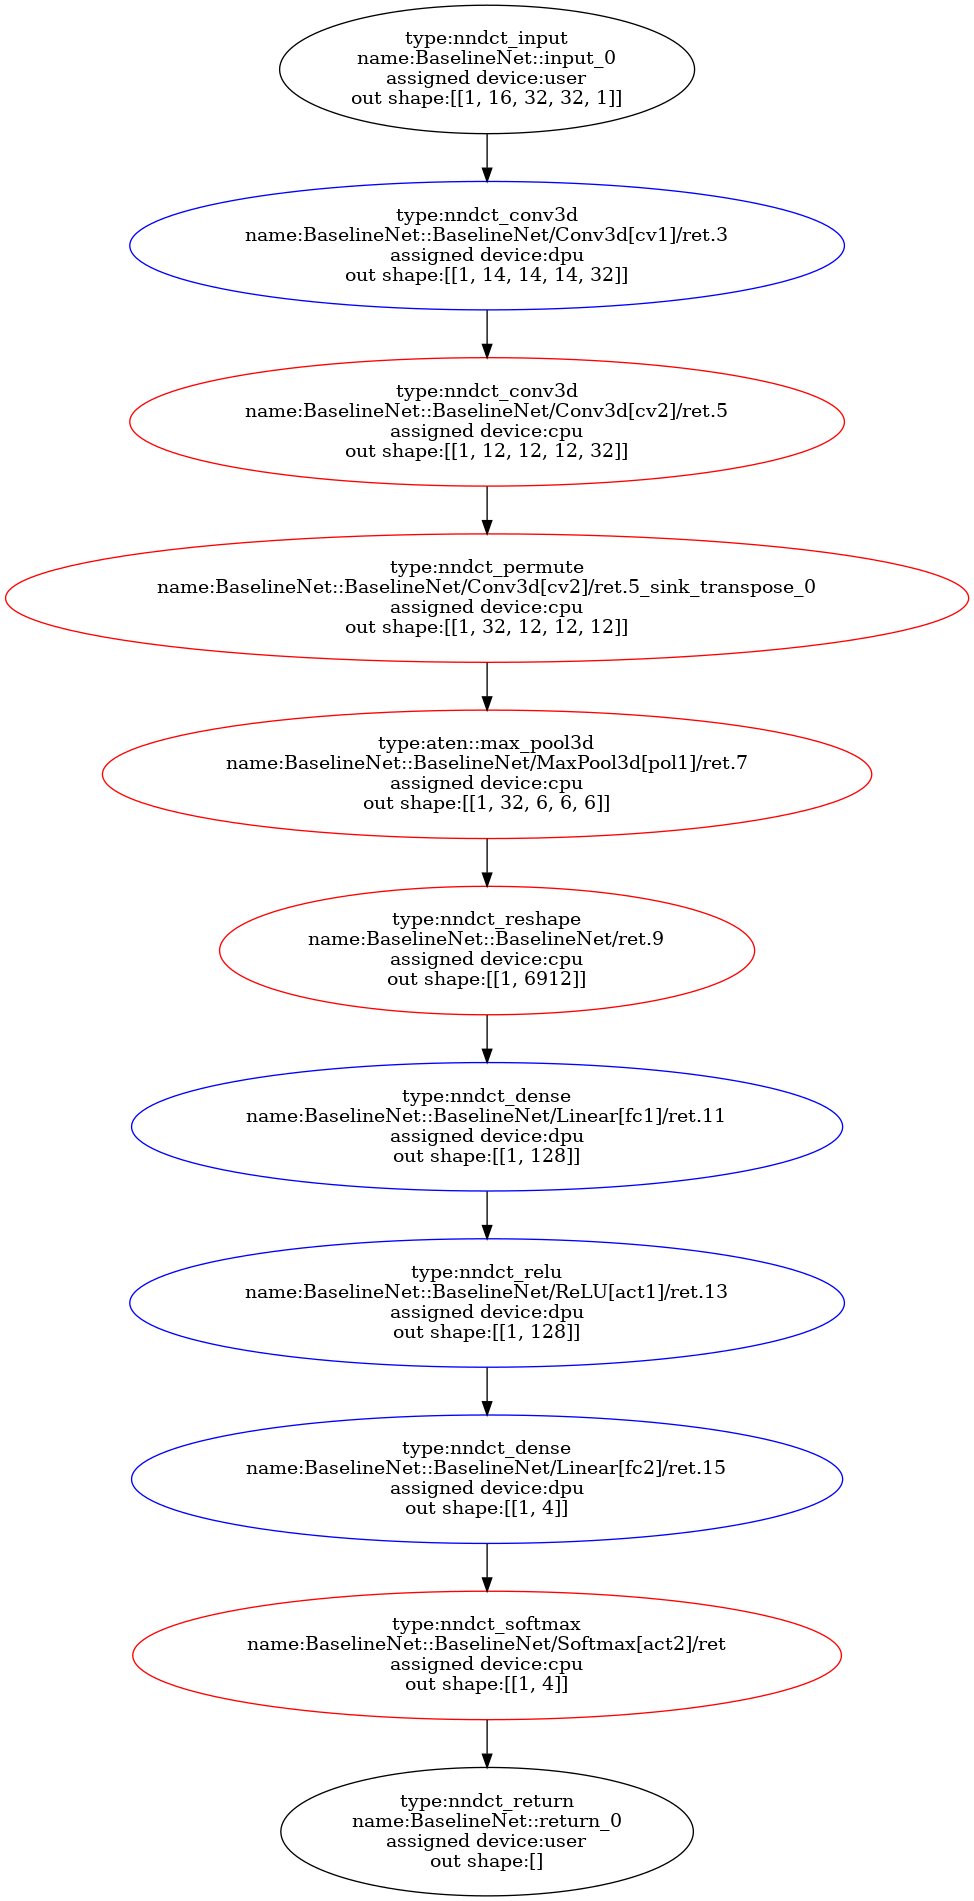

In [5]:
# Show the dot image
from IPython.display import Image
Image('inspect/inspect_DPUCAHX8L_ISA0_SP.png')